# Day 19 Pre-Class Assignment
---


### <p style="text-align: right;"> &#9989; Put your name here</p>

## Assessing statistical differences with the t-test and the importance of good visualizations

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/prediction.png" style="display:block; margin-left: auto; margin-right: auto; width: 60%" alt="This comic is about misunderstanding probability. Saying that one event is more likely to happen than another is not the same as saying that the first event is definitely going to happen. A statement like 'event A has a 70% probability of happening' sometimes misleads people into believing that event A is inevitable, while in fact 3 times out of 10 event A will not happen.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://xkcd.com/2370/" target="_blank">xkcd.com</a></p>

### Learning goals for today's pre-class assignment

* Be able to articulate what a t-test is and its three main flavors
* Use SciPy to compute a t-test and its associated p-value
* Interpret correctly the meaning of the p-value
* Emphasize the need for good data visualization to guide our statistical conclusions.

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

----

## 1. Introduction to one- and two-sample t-tests

In many applications, you'll find yourself taking measurements from different groups and then wondering if these groups are statistically the same or not. You might compare male vs female, control vs treatment, wild type vs mutation, day 1 vs day 20, etc. That is, you have **one** or **two** samples you want to compare. You need a one- or two-sample test.

The most common one- and two-sample tests&mdash;**very much obsolete**&mdash; are the [Student's t-test](https://en.wikipedia.org/wiki/Student%27s_t-test).

Watch the video below to learn more about (Student's) t-tests.

**Important: Do not worry too much about the math discussed across the video. The t-tests are outdated&mdash;but still taught due to inertia. There are much more powerful alternatives readily available in Python which we will discuss later**.

However, t-tests are a good entry point to the whole one- and two-sample test discussion we'll have below. Make note that early on, the video describes three kinds/types of t-tests which correspond to three null hypotheses:

> 1. There is no statistical difference between the mean of this *one* sample and this fixed value.
> 2. There is no statistical difference between the means of these *two independent* samples.
> 3. There is no statistical difference between the means of these *paired* samples.

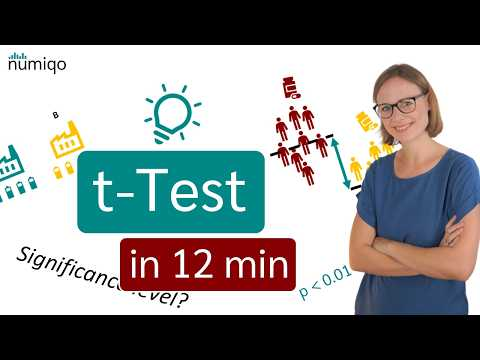

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo("a9liXroJyPg",width=640,height=360, end=9*60) 

&#9989;&nbsp; **Question 1**

- In your own words, explain the three main kinds/types of t-tests described in the video.

<font size=6 color="#009600">&#9998;</font> *Put your three answers here.*


&#9989;&nbsp; **Question 2**

Say you are hired as a data analyst for [MU's UDAIR](https://udair.missouri.edu/mu-data/student-enrollment/) (University Data, Analytics, and Institutional Research). You have access to all the (anonymized) student enrollment data.

- For each of the three t-test kinds, describe a question that you could answer with UDAIR's data and a t-test.

<font size=6 color="#009600">&#9998;</font> *Put your three answers here.*

*
*
*

---

## 2. Going through an example: contaminated pollen

<img src="https://ejamezquita.github.io/tutorials/figs/kettenbach_etal_2017_f4.svg" style="display:block; margin-left: auto; margin-right: auto; width: 60%" alt="Distribution of pollen contamination scores based on location of collection.">
<p style="font-size:0.85em; text-align: center;">Adapted from: <a href="https://doi.org/10.1002/ece3.3272" target="_blank">Kettenbach et al (2017)</a></p>

Let's revisit the data from contaminated pollen we saw in In-Class 15. The data above is adapted from [Kettenbach et al (2017)](https://doi.org/10.1002/ece3.3272), Figure 5. Kettenbach et al. took samples from pollen found on alpine skypilot plants (native) across different locations and altitudes in Colorado. The locations are Hoosier East (HE), Hoosier West (HW), and Weston Pass (WP). The y-axis is the percentage of pollen found that it is actually from willow (invasive).

(This same figure [can be opened in this tab](https://ejamezquita.github.io/tutorials/figs/kettenbach_etal_2017_f4.svg) if you prefer to switch windows instead of scrolling up and down.)

&#9989;&nbsp; **Question 3**

Say you are working in the Alpine Skypilot Lab. You want to know if the pollen is more contaminated in certain Colorado regions compared to others.

- Looking just at the data, which locations have similar contamination levels?
- Which locations have different levels?

Give it your best guess

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question 4**

Visualization is crucial. But so is statistics. It is the combination of both that can reveal the whole story.

- Which of the three t-test flavors is the correct one to use

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


### 2.1 Nuances of the p-value

For pre-class 15, you saw an explanation on the true meaning of a p-value. Every t-test comes with an associated p-value, from which **you** make a decision on whether you reject or keep the null hypothesis. In this case, the null hypothesis is:

> There is no statistical difference between the mean of these two samples.

The p-value indicates the probability that the differences you observe in the data&mdash;if any&mdash;are caused by sheer chance. So a large p-value will prevent you from rejecting the null hypothesis. Some important points to consider:

* Not rejecting the null hypothesis does **not** necessarily mean that the null hypothesis is true.

* A small p-value does **not** necessarily mean that the populations are different. It simply means that there is a very small chance that they are actually the same. It is a nuanced but important distinction.

* The p-value does **not** tell you **how** different two samples are. It just gives you an assessment on how likely the difference between samples is due to randomness.

* A p-value is just an indicator of which call *might* be the correct one, but ultimately **YOU** are the one who has to make the call. The best and only way to make that call is by combining *domain knowledge* and *data visualization*.

&#9989;&nbsp; **Question 4**

The real p-values for the independent samples t-tests are as follows:

|t-test Comparison | p-value |
|----------:|--------:|
|**HE vs HW**| 0.002 |
|**HE vs WP**| 0.756|
|**HW vs WP**| 2 &times;10<sup>-6</sup> |

Using *both* the table and the scatterplot, answer True or False for each statement *and explain your choice.* Go with your best guess.

1. Hoosier East and Weston Pass have similar levels of pollen contamination.
2. Hoosier East and Hoosier West have different levels of contamination.
3. Hoosier West is a 1000 times more different than Weston Pass.

<font size=6 color="#009600">&#9998;</font> *Put your three answers here.*

*
*
*

---

## 3. Welch's t-tests and a why you should never do a Student's t-test

As mentioned in the video above, for Student's t-tests to be valid, you need your samples have to be:
- Normally-ish distributed
- Homoscedastic _aka_ have the same variance or standard deviations

That requires you to check for these two prior conditions before doing Student's t-tests. However, with Welch's, you only need to check if your data is normal-ish. **Welch's t-tests are an alternative that do not require homoscedasticity**.

Historically, Student's was developed 50 years before Welch's. And the math and computations behind Welch's are much longer than those behind Student's. Back in the pre-computer days, it was too much work to compute Welch's, so people used almost exclusively Student's. And it stuck.

Ironically, it is a self-preserving cycle: people are only taught Student's t-tests. They publish actual research with Student's. And thus they keep teaching Student's to new generations, which in turn will use it and teach it. Break the cycle!

[In general **you should use Welch's t-test instead of Student's**](https://doi.org/10.5334/irsp.82). Welch's might be a bit off compared to Student's if your sample size is small (`n = 10` or less). But with small sample sizes, no test will be perfect.

---

## 4. Computing two independent-sample Welch's t-tests with SciPy

Just like with linear regressions,  SciPy's `stats` submodule can compute Welch's t-tests for us.

- [`stats.ttest_1samp` does](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html) a 1-sample t-test.
    - The first type: comparing whether one sample mean is the same as a fixed value.
    - The third type: comparing whether the mean difference between two samples is zero, which is equivalent to compare whether there was a significant change in the same sample.
- [`stats.ttest_ind` with the `equal_var = False`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) parameter does a 2-independent samples t-test.
    - The second type: comparing whether the means from two samples are statistically the same

### 4.1 The usual setup

We will use the same data from [Kettenbach et al (2017)](https://doi.org/10.1002/ece3.3272) discussed in Section 2.

Before doing any stats, as always, we import packages, load the data `2016+population+survey.csv`, and drop NaNs.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [3]:
data = pd.read_csv('2016+population+survey.csv').dropna(axis=0, how='any')
print(data.shape)
data.head()

(120, 7)


,site,sample ID,meters from Salix,no. flwrs on inflorescence,mean no. pv pollen grains,mean no. Salix pollen,frequency of Salix pollen
0,Pennsylvania Mountain,1.1,6.20,5,314,73,0.188630
1,Pennsylvania Mountain,1.2,4.65,11,187,51,0.214286
2,Pennsylvania Mountain,1.3,15.00,8,241,149,0.382051
3,Pennsylvania Mountain,1.4,18.10,4,185,88,0.322344
4,Pennsylvania Mountain,1.5,11.90,7,129,60,0.317460


Then we get three Series (1D DataFrame). Each Series contains the pollen contamination percentages found at each of the three sites we are studying. We name these three Series based on the site acronyms we used in Section 2.

&#9989;&nbsp; **Task 5**

- Comment what each of the lines below is doing

In [4]:
# Comment each line here
sites = ['Hoosier Pass - East', 'Hoosier Pass - West', 'Weston Pass']
contamination = []
for site in sites:
    pollen_site = data.loc[data['site'] == site, 'frequency of Salix pollen']
    contamination.append(pollen_site)
HE, HW, WP = contamination

&#9989;&nbsp; **Task 6: Your turn**

- [Use `stats.ttest_ind` to](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) compute the t-test and its associated p-value when comparing the pollen contamination differences across the three sites. (That means you need to compute three tests)?
- Do your values match the with those in the table in Section 2?

Remember to use the `equal_var = False` parameter to compute a Welch's t-test.

In [5]:
# Your code

&#9989;&nbsp; **Question 7**

Take a look at [Figure 5 from Kettenbach et al (2017)](https://onlinelibrary.wiley.com/cms/asset/cf86d0f7-e9c2-4be2-9b5e-4f95409c0a68/ece33272-fig-0004-m.jpg). It is the same data from Section 2 (with an additional site), except Kettenbach uses boxplots. Ignore the box corresponding to Pennsylvania Mountain.

- What do you think the `a` and `b`s mean on top of the boxplots?

Your best guess is fine. We'll discuss it in class tomorrow.

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


---

## 5. What if the data is not normally distributed? Do non-parametric tests!

Welch's t-test requires your samples to be normally distributed. Actually, normal-ish&mdash;we'll discuss more on the -ish next class. But sometimes, your data is clearly **not** even close to being normal. In that case, we can do non-parametric tests!

- To do one-sample or paired-sample tests, go for a [Wilcoxon signed-rank test](https://en.wikipedia.org/wiki/Wilcoxon_signed-rank_test).
    - You can compute it with [ the `stats.wilcoxon` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html).
- To do two independent sample tests, go for a [(Wilcoxon)-Mann-Whitney U-test](https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test).
    - You can compute it with [the `stats.mannwhitneyu` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).

Remember that a normal curve is a **parametric** distribution: we only need to know two *parameters* to draw it: mean and standard deviation. Tests that do not assume that data follows a specific parametric distribution&mdash;usually normal&mdash;are referred to a **non-parametric tests**.

The key idea behind all non-parametric tests is that they consider the **rank** of the datapoints instead of their actual numerical values. Think of how Pearson's correlation compares to Spearman's.

**Watch the first 2:30 minutes of the following video on U-tests.** (The rest of the video goes into how to use other software to make the computations, which we don't really need to know.)

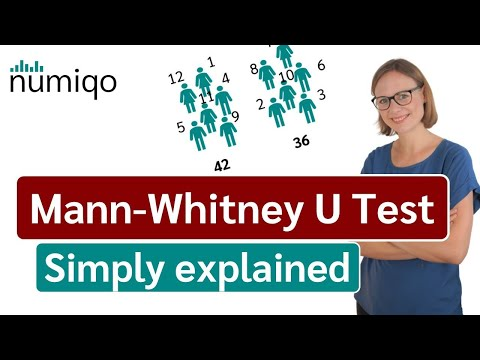

In [6]:
from IPython.display import YouTubeVideo
YouTubeVideo("LcxB56PzylA",width=640,height=360, end=2*60+30) 

### 5.1 So why don't we ditch Welch's and do U-tests all the time?

You might be tempted to ditch Welch's t-tests in favor of Mann-Whitney tests. With the latter you don't need to check for normality. It's a win!

However, there is no free lunch. While non-parametric tests have less requirements, they have less *power*. Non-parametric tests can be inaccurate if you have small sample sizes, or if the difference in sample means is small.

Watch the first 2:20 minutes of the following video to drive that point home.

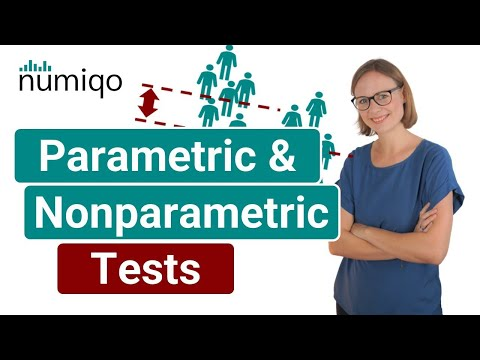

In [7]:
from IPython.display import YouTubeVideo
YouTubeVideo("ftnOBcXtBEQ",width=640,height=360, end=2*60+21) 

&#9989;&nbsp; **Question 8**

In your own words:
- What is the main difference(s) between a Welch's t-test and a Mann-Whitney U-test?
- Why is Pearson correlation considered a parametric test while Spearman correlation is called a non-parametric one?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri